# 01 – Explore CARVIS VIS_A Spectral Data (AU Microscopii)

This notebook loads and visualizes the high-resolution spectral observations of AU Microscopii obtained by the CARMENES instrument (visible arm). These are time-series echelle spectra stored in `*-vis_A.fits` files.

I will:
- List and inspect the available observations.
- Explore the HDU structure of the FITS files.
- Plot flux vs. wavelength for individual spectral orders.
- Visualize continuum and uncertainty.

In [14]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ImageNormalize, LogStretch, PercentileInterval

In [ ]:
fits_root = "../../aumicAE1"

with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

print(f"Loaded {len(vis_a_files)} resolved FITS file paths.")

Loaded 101 resolved FITS file paths.


## Inspect HDU Structure

Each file contains multiple HDUs with flux, continuum, uncertainty, and wavelength data for 61 echelle orders.

In [34]:
with fits.open(vis_a_files[0]) as hdul:
    hdul.info()

Filename: ../../aumicAE1/data/AUMic/CARVIS/car-20190714T01h22m54s-sci-gtoc-vis_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     465   ()      
  1  SPEC          1 ImageHDU         8   (4096, 61)   float32   
  2  CONT          1 ImageHDU         8   (4096, 61)   float32   
  3  SIG           1 ImageHDU         8   (4096, 61)   float32   
  4  WAVE          1 ImageHDU         8   (4096, 61)   float64   


## HDU Meaning

| HDU Index | Name  | Shape       | Description                                                                 |
|-----------|-------|-------------|------------------------------------------------------------------------------|
| 0         | PRIMARY | —          | Header only — no data here                                                  |
| 1         | SPEC  | (4096, 61)  | ! Flux: intensity values per pixel and order                               |
| 2         | CONT  | (4096, 61)  | Continuum: estimated baseline light level                                   |
| 3         | SIG   | (4096, 61)  | Uncertainty: standard deviation (1-σ error)                                 |
| 4         | WAVE  | (4096, 61)  | Wavelength: physical wavelength in Ångströms                                |


## Plot Spectrum of One Order

Let’s plot the flux, continuum, and uncertainty for one spectral order (e.g., order 30) from the first observation.


In [35]:
def plot_spectral_order(file_path, order_index):
    with fits.open(file_path) as hdul:
        flux = hdul['SPEC'].data[:, order_index]
        wave = hdul['WAVE'].data[:, order_index]
        cont = hdul['CONT'].data[:, order_index]
        sig  = hdul['SIG'].data[:, order_index]

    plt.figure(figsize=(10, 5))
    plt.plot(wave, flux, label='Flux', color='orange')
    plt.plot(wave, cont, '--', label='Continuum', color='blue', alpha=0.6)
    plt.fill_between(wave, flux - sig, flux + sig, color='gray', alpha=0.3, label='Uncertainty')
    plt.xlabel('Wavelength [Å]')
    plt.ylabel('Flux')
    plt.title(f"Spectrum of AU Mic – Order {order_index}")
    plt.legend()
    plt.tight_layout()

    os.makedirs("../outputs/plots", exist_ok=True)
    plt.savefig(f"../outputs/plots/spectrum_order_{order_index}.png", dpi=150)
    plt.show()

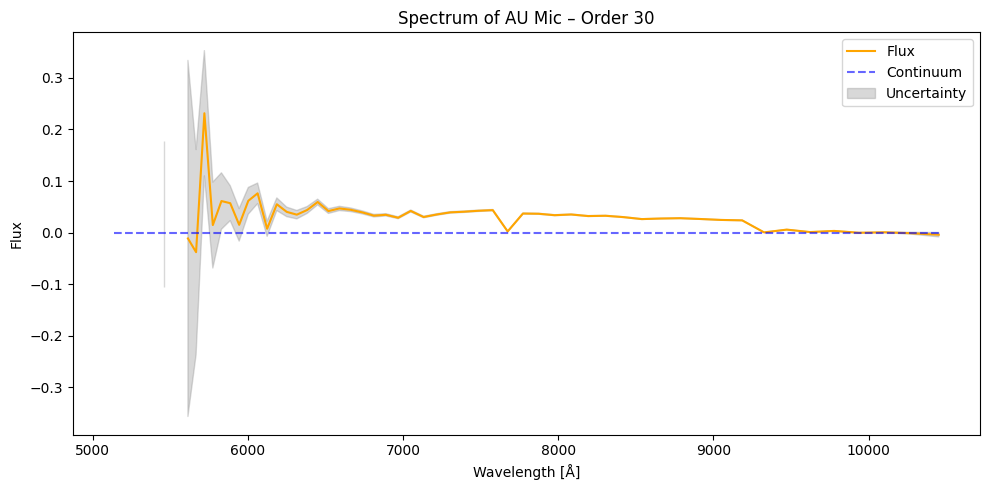

In [36]:
plot_spectral_order(vis_a_files[0], order_index=30)

The plot shows the flux of AU Microscopii in spectral order 30, with clear absorption features around a stable continuum between 6000 Å and 9000 Å, while both ends show higher uncertainty and lower signal quality, likely due to instrumental or order-edge effects.

## Visual Summary

- The spectrum shows intensity vs. wavelength.
- The continuum gives a baseline, useful for normalization.
- The uncertainty highlights noisy regions (typically order edges).


## Next Steps

In the next notebook, I will:

- Normalize the spectra (flux / continuum)
- Extract consistent input shapes
- Train autoencoders to learn compressed latent representations
- Track how those representations evolve over time

→ Go to: `02_prototype_autoencoder.ipynb`
